In [3]:
# read the spatial units
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from chord import Chord
import xvec
# import pyarrow

# import xesmf as xe

import warnings
warnings.filterwarnings('ignore')


## 0. Loading Data

In [6]:
data = pd.read_parquet(r'/home/kzakir/dvcube/test/data/mobility_data/mobility_data_processed.parquet')
spatial_data = gpd.read_parquet(r'/home/kzakir/dvcube/test/data/mobility_data/spatial_units_with_lat_lon.parquet')
print(data.head())
print(spatial_data.head())
print(spatial_data.crs)


               origin        destination  HalfMonthIndex  N_depart  N_return  \
0  SEN.14.3.1_1-rural  SEN.6.3.2_1-rural        20130301       0.0       0.0   
1  SEN.14.3.1_1-rural  SEN.6.3.2_1-rural        20130316       0.0       0.0   
2  SEN.14.3.1_1-rural  SEN.6.3.2_1-rural        20130401       0.0       0.0   
3  SEN.14.3.1_1-rural  SEN.6.3.2_1-rural        20130416       0.0       0.0   
4  SEN.14.3.1_1-rural  SEN.6.3.2_1-rural        20130501       0.0       0.0   

   rate_depart  rate_return  N_users_observed_depart  N_users_observed_return  \
0          0.0          0.0                   2091.0                   2091.0   
1          0.0          0.0                   2090.0                   2091.0   
2          0.0          0.0                   2091.0                   2089.0   
3          0.0          0.0                   2092.0                   2091.0   
4          0.0          0.0                   2100.0                   2091.0   

   N_migrants  ...  subset_type 

In [12]:
# rename norm_id to norm_spatial_id in spatial_data
spatial_data = spatial_data.rename(columns={'norm_id': 'norm_spatial_id'})

In [8]:
# add season to mobility data, to wet and dry season
#     df['season'] = np.where(df['month'].isin([11, 12, 1, 2, 3, 4]), 1, 2)  #
# take date we have date column in the data, we can extract month and year from it
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year

data['season'] = np.where(data['month'].isin([11, 12, 1, 2, 3, 4]), 'wet', 'dry')
data['season'] = data['season'].astype('category')
data

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type,month,year,season
0,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.0,0.0,0.000000,0.0,2091.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-01,rural,rural,rural → rural,3,2013,wet
1,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.0,0.0,0.000000,0.0,2090.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-16,rural,rural,rural → rural,3,2013,wet
2,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130401,0.0,0.0,0.000000,0.0,2091.0,2089.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-01,rural,rural,rural → rural,4,2013,wet
3,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130416,0.0,0.0,0.000000,0.0,2092.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-16,rural,rural,rural → rural,4,2013,wet
4,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130501,0.0,0.0,0.000000,0.0,2100.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-05-01,rural,rural,rural → rural,5,2013,dry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17032795,city-008,city-017,20151001,0.0,0.0,0.000000,0.0,1949.0,1952.0,0.0,...,city-017,Diaobé,Kébémer,2015-10-01,urban,urban,urban → urban,10,2015,dry
17032796,city-008,city-017,20151016,0.0,0.0,0.000000,0.0,1938.0,1949.0,0.0,...,city-017,Diaobé,Kébémer,2015-10-16,urban,urban,urban → urban,10,2015,dry
17032797,city-008,city-017,20151101,0.0,0.0,0.000000,0.0,1933.0,1940.0,0.0,...,city-017,Diaobé,Kébémer,2015-11-01,urban,urban,urban → urban,11,2015,wet
17032798,city-008,city-017,20151116,0.0,0.0,0.000000,0.0,1924.0,1933.0,0.0,...,city-017,Diaobé,Kébémer,2015-11-16,urban,urban,urban → urban,11,2015,wet


In [22]:
mob_with_dakar = data.copy()
# remove dakar from irign and destination, because we want to see the mobility outside of dakar
mob_without_dakar = mob_with_dakar[(mob_with_dakar['origin_name'] != 'Dakar') & (mob_with_dakar['destination_name'] != 'Dakar')]
mob_without_dakar

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type,month,year,season
0,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.0,0.0,0.000000,0.0,2091.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-01,rural,rural,rural → rural,3,2013,wet
1,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.0,0.0,0.000000,0.0,2090.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-16,rural,rural,rural → rural,3,2013,wet
2,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130401,0.0,0.0,0.000000,0.0,2091.0,2089.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-01,rural,rural,rural → rural,4,2013,wet
3,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130416,0.0,0.0,0.000000,0.0,2092.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-16,rural,rural,rural → rural,4,2013,wet
4,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130501,0.0,0.0,0.000000,0.0,2100.0,2091.0,0.0,...,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-05-01,rural,rural,rural → rural,5,2013,dry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17032795,city-008,city-017,20151001,0.0,0.0,0.000000,0.0,1949.0,1952.0,0.0,...,city-017,Diaobé,Kébémer,2015-10-01,urban,urban,urban → urban,10,2015,dry
17032796,city-008,city-017,20151016,0.0,0.0,0.000000,0.0,1938.0,1949.0,0.0,...,city-017,Diaobé,Kébémer,2015-10-16,urban,urban,urban → urban,10,2015,dry
17032797,city-008,city-017,20151101,0.0,0.0,0.000000,0.0,1933.0,1940.0,0.0,...,city-017,Diaobé,Kébémer,2015-11-01,urban,urban,urban → urban,11,2015,wet
17032798,city-008,city-017,20151116,0.0,0.0,0.000000,0.0,1924.0,1933.0,0.0,...,city-017,Diaobé,Kébémer,2015-11-16,urban,urban,urban → urban,11,2015,wet


## 1. Choropleth map based on seasonal mobility

For choropleth, we first need to aggregate mobility to each spatial unit. We can do this as:

- **outflow:** people leaving each unit;
- **inflow:** people arriving into each unit;
- **net mobility:** inflow minus outflow;
- **total mobility:** inflow plus outflow.

### 2. Reusable function for seasonal mobility aggregation

In [23]:
def make_seasonal_mobility(
    mob_df,
    origin_id_col="norm_spatial_id_origin",
    dest_id_col="norm_spatial_id_destination",
    flow_col="flow",
    season_col="season",
    unit_id_col="norm_spatial_id"
):
    # Outflow
    outflow = (
        mob_df.groupby([origin_id_col, season_col])[flow_col]
        .sum()
        .reset_index()
        .rename(columns={
            origin_id_col: unit_id_col,
            flow_col: "outflow"
        })
    )

    # Inflow
    inflow = (
        mob_df.groupby([dest_id_col, season_col])[flow_col]
        .sum()
        .reset_index()
        .rename(columns={
            dest_id_col: unit_id_col,
            flow_col: "inflow"
        })
    )

    seasonal = outflow.merge(
        inflow,
        on=[unit_id_col, season_col],
        how="outer"
    )

    seasonal["outflow"] = seasonal["outflow"].fillna(0)
    seasonal["inflow"] = seasonal["inflow"].fillna(0)

    seasonal["net_mobility"] = seasonal["inflow"] - seasonal["outflow"]
    seasonal["total_mobility"] = seasonal["inflow"] + seasonal["outflow"]

    return seasonal

In [25]:

seasonal_with_dakar = make_seasonal_mobility(mob_with_dakar, flow_col="N_depart")
seasonal_without_dakar = make_seasonal_mobility(mob_without_dakar, flow_col="N_depart")
seasonal_with_dakar

,norm_spatial_id,season,outflow,inflow,net_mobility,total_mobility
0,city-001,dry,403680.219697,108387.532879,-295292.686818,512067.752576
1,city-001,wet,133077.081912,101015.077533,-32062.004379,234092.159446
2,city-002,dry,271569.716267,256587.677470,-14982.038796,528157.393737
3,city-002,wet,109317.656103,123092.186111,13774.530008,232409.842214
4,city-004,dry,58368.129752,64294.593702,5926.463950,122662.723454
...,...,...,...,...,...,...
297,sen.9.2.1,wet,127887.470211,97705.688711,-30181.781501,225593.158922
298,sen.9.2.2,dry,326234.535996,324481.001128,-1753.534868,650715.537124
299,sen.9.2.2,wet,178856.550237,193891.442806,15034.892568,372747.993043
300,sen.9.3.1,dry,158779.216998,169104.320925,10325.103928,327883.537923


In [2]:
# seasonal_without_dakar

### Choropleth map with and without Dakar

In [31]:
def plot_seasonal_choropleth(
    units,
    seasonal_mobility,
    season_name,
    value_col="outflow",
    title_suffix="with Dakar",
    unit_id_col="norm_spatial_id",
    season_col="season",
    cmap="OrRd"
):
    map_df = units.merge(
        seasonal_mobility[seasonal_mobility[season_col] == season_name],
        on=unit_id_col,
        how="left"
    )

    map_df[value_col] = map_df[value_col].fillna(0)

    fig, ax = plt.subplots(figsize=(10, 10))

    map_df.plot(
        column=value_col,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="white",
        legend=True,
        # bar to be horizontal and at the bottom of the map position
        legend_kwds={"orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "No data"}
    )

    ax.set_title(
        f"{value_col.replace('_', ' ').title()} - {season_name} ({title_suffix})",
        fontsize=14
    )
    ax.axis("off")

    plt.tight_layout()
    plt.show()

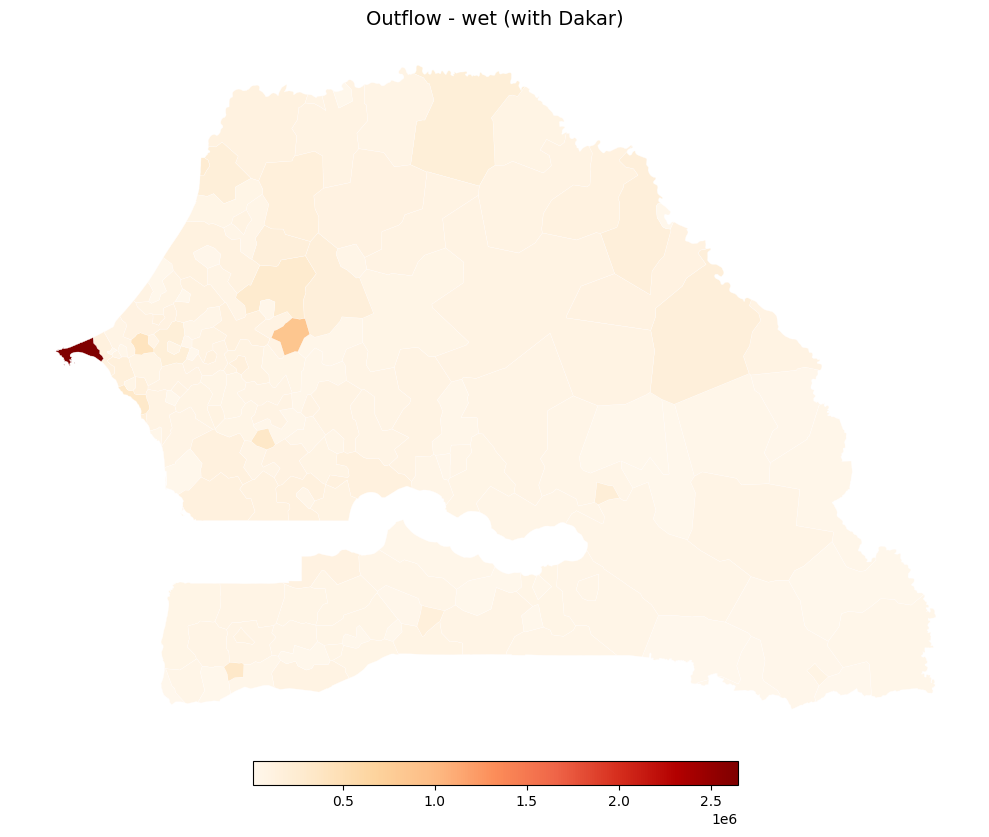

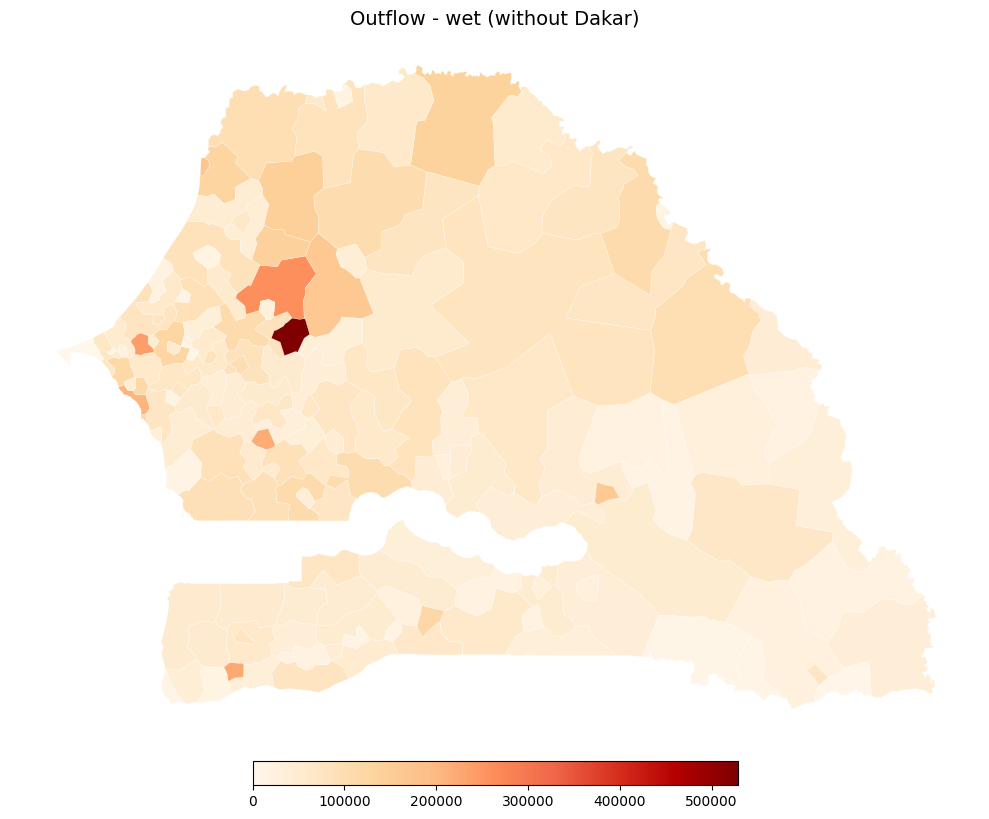

In [32]:
season_name = "wet"

plot_seasonal_choropleth(
    spatial_data,
    seasonal_with_dakar,
    season_name,
    value_col="outflow",
    title_suffix="with Dakar",
    cmap="OrRd"
)

plot_seasonal_choropleth(
    spatial_data,
    seasonal_without_dakar,
    season_name,
    value_col="outflow",
    title_suffix="without Dakar",
    cmap="OrRd"
)

In [ ]:
def plot_with_without_dakar_maps(
    units,
    seasonal_with_dakar,
    seasonal_without_dakar,
    season_name,
    value_col="outflow",
    unit_id_col="norm_spatial_id",
    season_col="season",
    cmap="OrRd",
    min_max=True
):
    map_with = units.merge(
        seasonal_with_dakar[seasonal_with_dakar[season_col] == season_name],
        on=unit_id_col,
        how="left"
    )

    map_without = units.merge(
        seasonal_without_dakar[seasonal_without_dakar[season_col] == season_name],
        on=unit_id_col,
        how="left"
    )

    map_with[value_col] = map_with[value_col].fillna(0)
    map_without[value_col] = map_without[value_col].fillna(0)

    # Use same scale for fair comparison
    if min_max:
        vmin = min(map_with[value_col].min(), map_without[value_col].min())
        vmax = max(map_with[value_col].max(), map_without[value_col].max())
    else:
        vmin = None
        vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(18, 9))

    map_with.plot(
        column=value_col,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="white",
        legend=True,
        legend_kwds={"orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
        vmin=vmin,
        vmax=vmax,
        ax=axes[0]
    )

    axes[0].set_title(f"{value_col.replace('_', ' ').title()} - {season_name} with Dakar")
    axes[0].axis("off")

    map_without.plot(
        column=value_col,
        cmap=cmap,
        linewidth=0.4,
        edgecolor="white",
        legend=True,
        legend_kwds={"orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
        vmin=vmin,
        vmax=vmax,
        ax=axes[1]
    )

    axes[1].set_title(f"{value_col.replace('_', ' ').title()} - {season_name} without Dakar")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

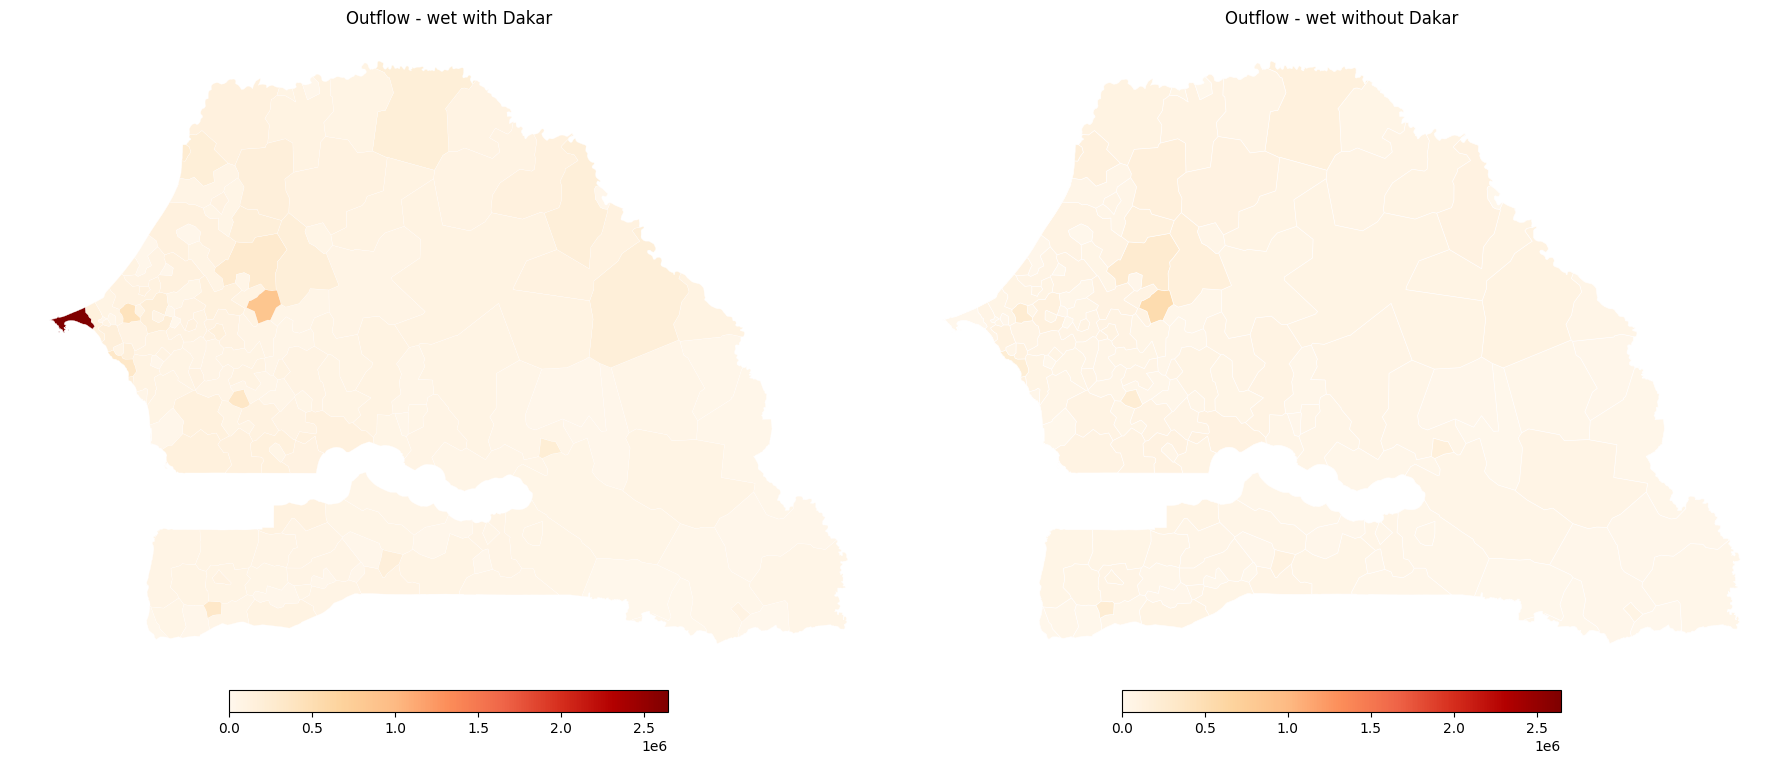

In [37]:
plot_with_without_dakar_maps(
    spatial_data,
    seasonal_with_dakar,
    seasonal_without_dakar,
    season_name="wet",
    value_col="outflow",
    cmap="OrRd"
)

### Distance Decay

In [38]:
def add_od_distance(
    mob_df,
    units,
    origin_id_col="norm_spatial_id_origin",
    dest_id_col="norm_spatial_id_destination",
    unit_id_col="norm_spatial_id",
    metric_crs="EPSG:32628"
):
    units_m = units.to_crs(metric_crs).copy()
    units_m["centroid"] = units_m.geometry.centroid

    centroids = units_m[[unit_id_col, "centroid"]].copy()

    df = mob_df.copy()

    df = df.merge(
        centroids.rename(columns={
            unit_id_col: origin_id_col,
            "centroid": "origin_centroid"
        }),
        on=origin_id_col,
        how="left"
    )

    df = df.merge(
        centroids.rename(columns={
            unit_id_col: dest_id_col,
            "centroid": "destination_centroid"
        }),
        on=dest_id_col,
        how="left"
    )

    df["distance_km"] = df.apply(
        lambda row: row["origin_centroid"].distance(row["destination_centroid"]) / 1000
        if row["origin_centroid"] is not None and row["destination_centroid"] is not None
        else np.nan,
        axis=1
    )

    return df

In [1]:
mob_dist_with = add_od_distance(mob_with_dakar, spatial_data)
# mob_dist_without = add_od_distance(mob_without_dakar, spatial_data)

NameError: name 'add_od_distance' is not defined

In [ ]:
def plot_distance_decay_comparison(
    mob_dist_with,
    mob_dist_without,
    flow_col="flow"
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, df, title in [
        (axes[0], mob_dist_with, "With Dakar"),
        (axes[1], mob_dist_without, "Without Dakar")
    ]:
        plot_df = df[
            (df[flow_col] > 0) &
            (df["distance_km"].notna())
        ].copy()

        ax.scatter(
            plot_df["distance_km"],
            plot_df[flow_col],
            alpha=0.25
        )

        ax.set_yscale("log")
        ax.set_xlabel("Distance between origin and destination (km)")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Mobility flow, log scale")

    fig.suptitle("Distance-decay of mobility flows with and without Dakar", fontsize=15)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_distance_decay_comparison(
    mob_dist_with,
    mob_dist_without,
    flow_col="N_depart"
)

### 6. Distance bands with and without Dakar

In [ ]:
def distance_band_summary(
    mob_dist,
    flow_col="flow"
):
    df = mob_dist[
        (mob_dist[flow_col] > 0) &
        (mob_dist["distance_km"].notna())
    ].copy()

    bins = [0, 25, 50, 100, 200, 400, 800, 1500]
    labels = ["0–25", "25–50", "50–100", "100–200", "200–400", "400–800", "800+"]

    df["distance_band_km"] = pd.cut(
        df["distance_km"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    summary = (
        df.groupby("distance_band_km", observed=True)
        .agg(
            total_flow=(flow_col, "sum"),
            mean_flow=(flow_col, "mean"),
            od_pairs=(flow_col, "count")
        )
        .reset_index()
    )

    return summary

In [ ]:
band_with = distance_band_summary(mob_dist_with, flow_col=flow_col)
band_with["version"] = "With Dakar"

band_without = distance_band_summary(mob_dist_without, flow_col=flow_col)
band_without["version"] = "Without Dakar"

band_all = pd.concat([band_with, band_without], ignore_index=True)

band_all

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for version, group in band_all.groupby("version"):
    ax.plot(
        group["distance_band_km"].astype(str),
        group["total_flow"],
        marker="o",
        label=version
    )

ax.set_xlabel("Distance band (km)")
ax.set_ylabel("Total mobility flow")
ax.set_title("Mobility flow by distance band with and without Dakar")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()